In [11]:
from google.colab import files
uploaded = files.upload()

Saving gold_match.csv to gold_match (2).csv
Saving gold_match_context.csv to gold_match_context (1).csv


In [12]:
match = pd.read_csv("gold_match.csv")
context = pd.read_csv("gold_match_context.csv")

print("Match shape:", match.shape)
print("Context shape:", context.shape)

Match shape: (142, 27)
Context shape: (142, 35)


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded ✅")

Libraries loaded ✅


In [16]:
df = context.merge(match, on="match_id", how="left")

# ✅ CORRECT column name
df = df[df["is_home_match"] == True]

df["match_date"] = pd.to_datetime(df["match_date_x"])
df = df.sort_values("match_date")

print("Merged dataset shape:", df.shape)
print(df.head())

Merged dataset shape: (71, 62)
                    match_id match_date_x  weather_temp_max_c  \
1  d256yo3eng04m0fu7b4sl7wno   2022-07-30                25.8   
3  d4mn5ksbxuvnaww4pmommxhqs   2022-08-14                32.2   
5  d65hmi7sq03yzr5he1k7ypus4   2022-08-27                21.0   
7  d80mkemezkz16bqh6lbn8tlhw   2022-09-10                18.9   
9  dak40etbhbqsr1nxyt50qcg0k   2022-10-01                17.8   

   weather_temp_min_c  weather_temp_mean_c  weather_precipitation_mm  \
1                12.9                 19.8                       0.0   
3                17.3                 25.4                       0.0   
5                15.9                 18.7                       0.0   
7                13.6                 15.7                       8.6   
9                10.9                 14.2                       9.8   

   weather_rain_mm  weather_snowfall_cm  weather_windspeed_max_kmh  \
1              0.0                  0.0                       10.2   
3    

In [17]:
print("Target variable (tickets_scanned):")
print(df["tickets_scanned"].describe())
print("\nAny missing values:", df["tickets_scanned"].isnull().sum())

Target variable (tickets_scanned):
count       71.000000
mean      6861.577465
std       1996.145941
min       3537.000000
25%       5425.000000
50%       6399.000000
75%       8015.000000
max      11069.000000
Name: tickets_scanned, dtype: float64

Any missing values: 0


In [18]:
# ✅ Kickoff hour
df["kickoff_hour"] = pd.to_datetime(df["kickoff_time_local"]).dt.hour

# ✅ Kickoff category
def kickoff_category(hour):
    if hour < 14:
        return "Early (Before 2PM)"
    elif hour < 17:
        return "Afternoon (2-5PM)"
    else:
        return "Evening (After 5PM)"

df["kickoff_category"] = df["kickoff_hour"].apply(kickoff_category)

# ✅ Season phase
def season_phase(matchday):
    if matchday <= 10:
        return "Early Season"
    elif matchday <= 25:
        return "Mid Season"
    else:
        return "Late Season"

df["season_phase"] = df["matchday"].apply(season_phase)

# ✅ Month
df["month"] = df["match_date"].dt.month
df["month_name"] = df["match_date"].dt.month_name()

print("Features created ✅")
print(df[["kickoff_hour","kickoff_category","season_phase","month_name"]].head())

Features created ✅
   kickoff_hour     kickoff_category  season_phase month_name
1            18  Evening (After 5PM)  Early Season       July
3            18  Evening (After 5PM)  Early Season     August
5            18  Evening (After 5PM)  Early Season     August
7            20  Evening (After 5PM)  Early Season  September
9            16    Afternoon (2-5PM)  Early Season    October


/tmp/ipykernel_12329/2295410180.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["kickoff_hour"] = pd.to_datetime(df["kickoff_time_local"]).dt.hour


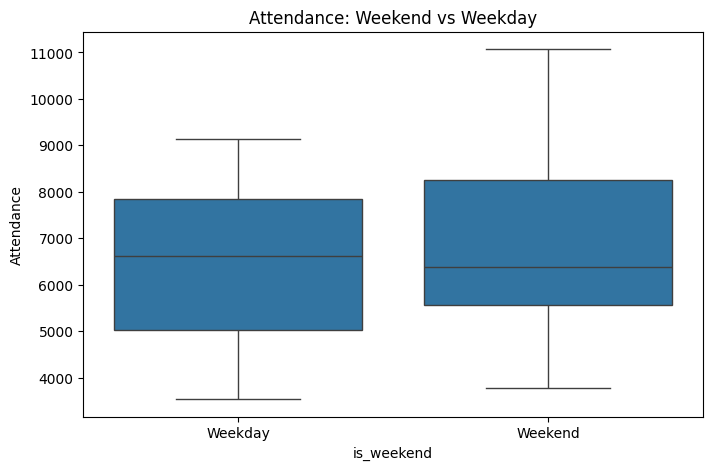

In [19]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_weekend", y="tickets_scanned", data=df)
plt.title("Attendance: Weekend vs Weekday")
plt.xticks([0,1], ["Weekday", "Weekend"])
plt.ylabel("Attendance")
plt.show()

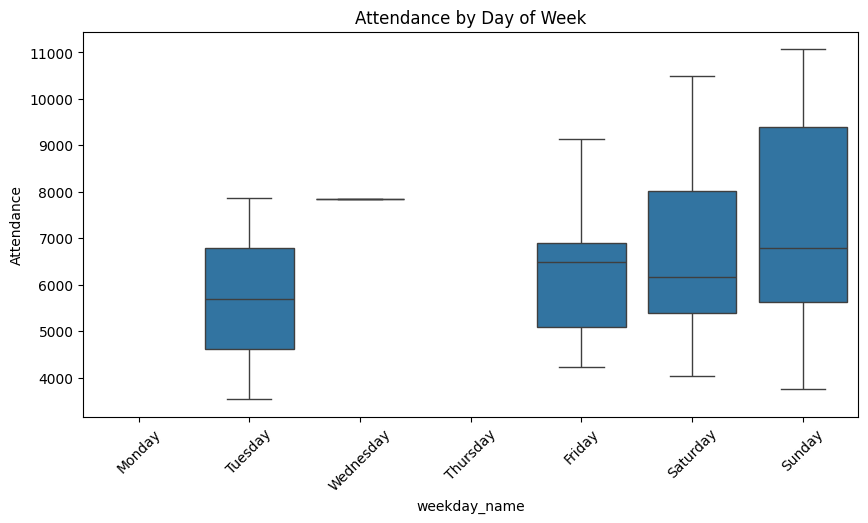

In [20]:
day_order = ["Monday","Tuesday","Wednesday",
             "Thursday","Friday","Saturday","Sunday"]

plt.figure(figsize=(10,5))
sns.boxplot(x="weekday_name", y="tickets_scanned", data=df, order=day_order)
plt.title("Attendance by Day of Week")
plt.xticks(rotation=45)
plt.ylabel("Attendance")
plt.show()

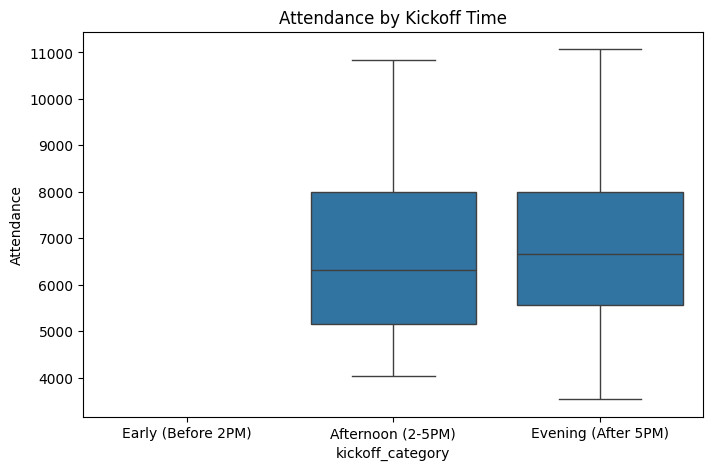

In [21]:
plt.figure(figsize=(8,5))
sns.boxplot(x="kickoff_category", y="tickets_scanned", data=df,
            order=["Early (Before 2PM)","Afternoon (2-5PM)","Evening (After 5PM)"])
plt.title("Attendance by Kickoff Time")
plt.ylabel("Attendance")
plt.show()

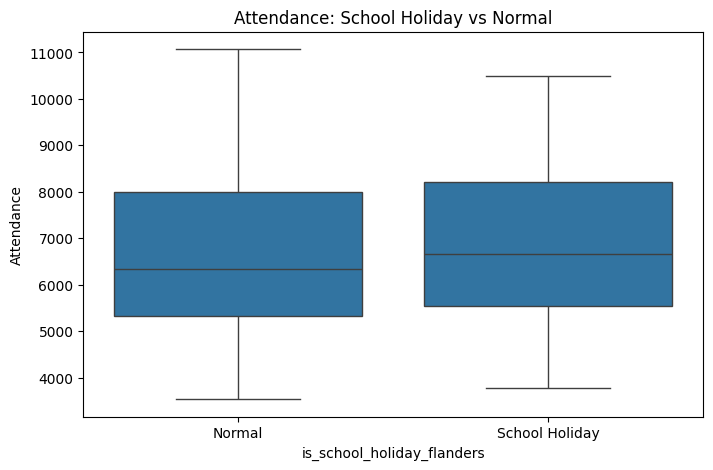

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_school_holiday_flanders", y="tickets_scanned", data=df)
plt.title("Attendance: School Holiday vs Normal")
plt.xticks([0,1], ["Normal", "School Holiday"])
plt.ylabel("Attendance")
plt.show()

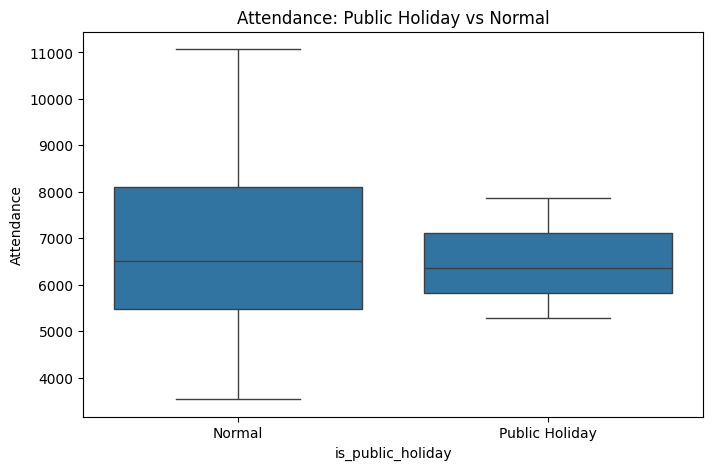

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x="is_public_holiday", y="tickets_scanned", data=df)
plt.title("Attendance: Public Holiday vs Normal")
plt.xticks([0,1], ["Normal", "Public Holiday"])
plt.ylabel("Attendance")
plt.show()

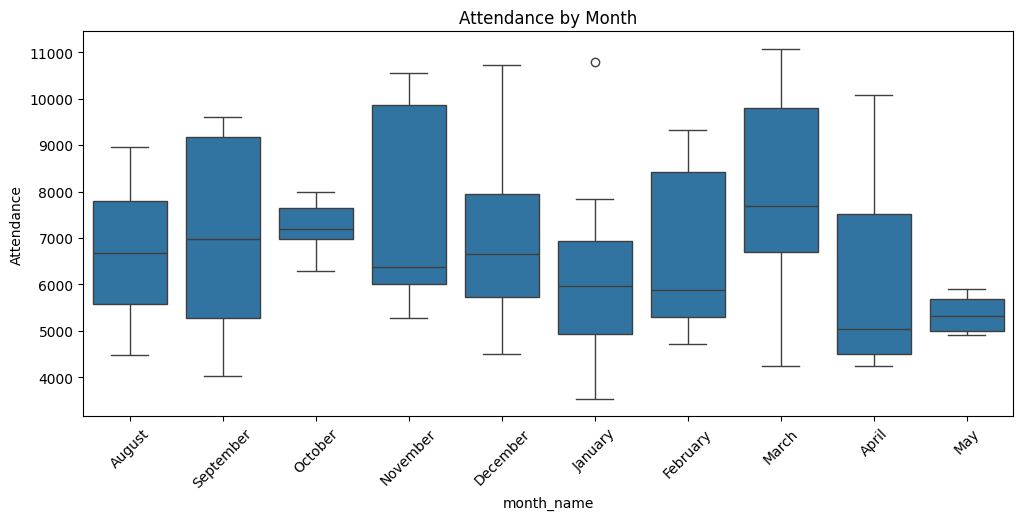

In [24]:
month_order = ["August","September","October","November","December",
               "January","February","March","April","May"]

plt.figure(figsize=(12,5))
sns.boxplot(x="month_name", y="tickets_scanned", data=df, order=month_order)
plt.title("Attendance by Month")
plt.xticks(rotation=45)
plt.ylabel("Attendance")
plt.show()

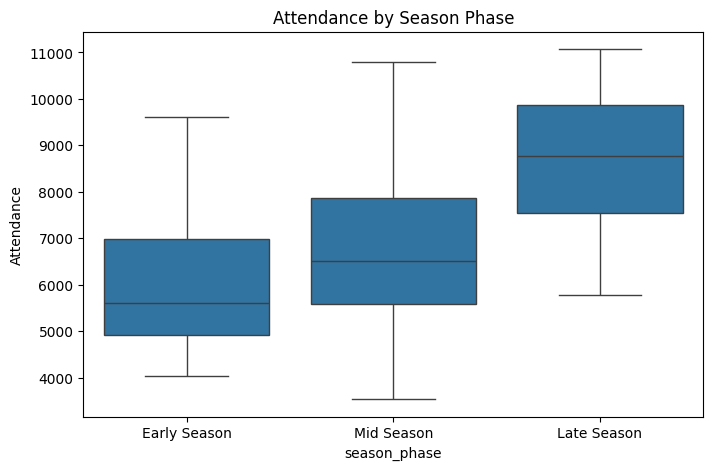

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x="season_phase", y="tickets_scanned", data=df,
            order=["Early Season","Mid Season","Late Season"])
plt.title("Attendance by Season Phase")
plt.ylabel("Attendance")
plt.show()

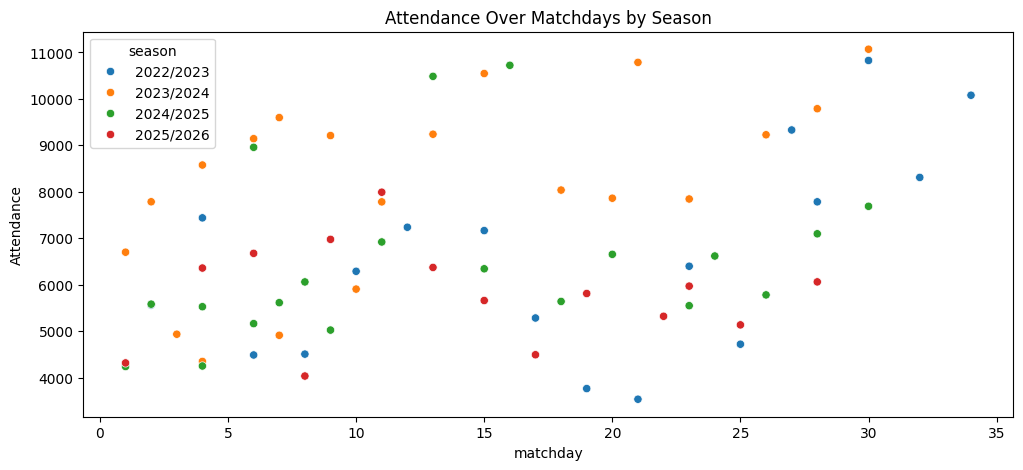

In [26]:
plt.figure(figsize=(12,5))
sns.scatterplot(x="matchday", y="tickets_scanned", hue="season", data=df)
plt.title("Attendance Over Matchdays by Season")
plt.ylabel("Attendance")
plt.show()

In [27]:
print("=== WEEKEND VS WEEKDAY ===")
print(df.groupby("is_weekend")["tickets_scanned"].mean())

print("\n=== DAY OF WEEK ===")
print(df.groupby("weekday_name")["tickets_scanned"].mean().sort_values(ascending=False))

print("\n=== KICKOFF CATEGORY ===")
print(df.groupby("kickoff_category")["tickets_scanned"].mean().sort_values(ascending=False))

print("\n=== SCHOOL HOLIDAY ===")
print(df.groupby("is_school_holiday_flanders")["tickets_scanned"].mean())

print("\n=== PUBLIC HOLIDAY ===")
print(df.groupby("is_public_holiday")["tickets_scanned"].mean())

print("\n=== SEASON PHASE ===")
print(df.groupby("season_phase")["tickets_scanned"].mean())

print("\n=== MONTH ===")
print(df.groupby("month_name")["tickets_scanned"].mean().sort_values(ascending=False))

=== WEEKEND VS WEEKDAY ===
is_weekend
False    6373.076923
True     6971.068966
Name: tickets_scanned, dtype: float64

=== DAY OF WEEK ===
weekday_name
Wednesday    7846.000000
Sunday       7266.392857
Saturday     6695.433333
Friday       6360.400000
Tuesday      5700.000000
Name: tickets_scanned, dtype: float64

=== KICKOFF CATEGORY ===
kickoff_category
Evening (After 5PM)    6926.285714
Afternoon (2-5PM)      6717.454545
Name: tickets_scanned, dtype: float64

=== SCHOOL HOLIDAY ===
is_school_holiday_flanders
False    6877.530612
True     6826.045455
Name: tickets_scanned, dtype: float64

=== PUBLIC HOLIDAY ===
is_public_holiday
False    6877.411765
True     6502.666667
Name: tickets_scanned, dtype: float64

=== SEASON PHASE ===
season_phase
Early Season    6145.137931
Late Season     8587.333333
Mid Season      6863.833333
Name: tickets_scanned, dtype: float64

=== MONTH ===
month_name
March        7917.777778
November     7704.857143
October      7231.833333
September    7076.42857

In [28]:
print("=== WEEKEND VS WEEKDAY ===")
print(df.groupby("is_weekend")["tickets_scanned"].mean())

print("\n=== DAY OF WEEK ===")
print(df.groupby("weekday_name")["tickets_scanned"].mean().sort_values(ascending=False))

print("\n=== KICKOFF CATEGORY ===")
print(df.groupby("kickoff_category")["tickets_scanned"].mean().sort_values(ascending=False))

print("\n=== SCHOOL HOLIDAY ===")
print(df.groupby("is_school_holiday_flanders")["tickets_scanned"].mean())

print("\n=== PUBLIC HOLIDAY ===")
print(df.groupby("is_public_holiday")["tickets_scanned"].mean())

print("\n=== SEASON PHASE ===")
print(df.groupby("season_phase")["tickets_scanned"].mean())

print("\n=== MONTH ===")
print(df.groupby("month_name")["tickets_scanned"].mean().sort_values(ascending=False))

=== WEEKEND VS WEEKDAY ===
is_weekend
False    6373.076923
True     6971.068966
Name: tickets_scanned, dtype: float64

=== DAY OF WEEK ===
weekday_name
Wednesday    7846.000000
Sunday       7266.392857
Saturday     6695.433333
Friday       6360.400000
Tuesday      5700.000000
Name: tickets_scanned, dtype: float64

=== KICKOFF CATEGORY ===
kickoff_category
Evening (After 5PM)    6926.285714
Afternoon (2-5PM)      6717.454545
Name: tickets_scanned, dtype: float64

=== SCHOOL HOLIDAY ===
is_school_holiday_flanders
False    6877.530612
True     6826.045455
Name: tickets_scanned, dtype: float64

=== PUBLIC HOLIDAY ===
is_public_holiday
False    6877.411765
True     6502.666667
Name: tickets_scanned, dtype: float64

=== SEASON PHASE ===
season_phase
Early Season    6145.137931
Late Season     8587.333333
Mid Season      6863.833333
Name: tickets_scanned, dtype: float64

=== MONTH ===
month_name
March        7917.777778
November     7704.857143
October      7231.833333
September    7076.42857

In [29]:
# ✅ Weekend effect
weekend_avg = df[df["is_weekend"]==True]["tickets_scanned"].mean()
weekday_avg = df[df["is_weekend"]==False]["tickets_scanned"].mean()
print(f"Weekend effect: +{weekend_avg - weekday_avg:.0f} spectators")

# ✅ School holiday effect
holiday_avg = df[df["is_school_holiday_flanders"]==True]["tickets_scanned"].mean()
normal_avg = df[df["is_school_holiday_flanders"]==False]["tickets_scanned"].mean()
print(f"School holiday effect: {holiday_avg - normal_avg:+.0f} spectators")

# ✅ Public holiday effect
pub_avg = df[df["is_public_holiday"]==True]["tickets_scanned"].mean()
nopub_avg = df[df["is_public_holiday"]==False]["tickets_scanned"].mean()
print(f"Public holiday effect: {pub_avg - nopub_avg:+.0f} spectators")

# ✅ Kickoff time effect
for cat in ["Early (Before 2PM)","Afternoon (2-5PM)","Evening (After 5PM)"]:
    avg = df[df["kickoff_category"]==cat]["tickets_scanned"].mean()
    print(f"{cat} average: {avg:.0f} spectators")

Weekend effect: +598 spectators
School holiday effect: -51 spectators
Public holiday effect: -375 spectators
Early (Before 2PM) average: nan spectators
Afternoon (2-5PM) average: 6717 spectators
Evening (After 5PM) average: 6926 spectators


In [30]:
# How many matches per category?
print("=== SAMPLE SIZES ===")
print("\nWeekend:", df["is_weekend"].value_counts())
print("\nDay:", df["weekday_name"].value_counts())
print("\nKickoff:", df["kickoff_category"].value_counts())
print("\nSchool Holiday:", df["is_school_holiday_flanders"].value_counts())
print("\nPublic Holiday:", df["is_public_holiday"].value_counts())
print("\nSeason Phase:", df["season_phase"].value_counts())

=== SAMPLE SIZES ===

Weekend: is_weekend
True     58
False    13
Name: count, dtype: int64

Day: weekday_name
Saturday     30
Sunday       28
Friday       10
Tuesday       2
Wednesday     1
Name: count, dtype: int64

Kickoff: kickoff_category
Evening (After 5PM)    49
Afternoon (2-5PM)      22
Name: count, dtype: int64

School Holiday: is_school_holiday_flanders
False    49
True     22
Name: count, dtype: int64

Public Holiday: is_public_holiday
False    68
True      3
Name: count, dtype: int64

Season Phase: season_phase
Mid Season      30
Early Season    29
Late Season     12
Name: count, dtype: int64
